# 05 - Evaluation and 7-day Forecast

**Author:** Juan Ruelas  
**Date:** 2026-05

We close the loop:

1. Score every model on the 2019 hold-out (MAE, RMSE, MAPE).
2. Compare actual vs predicted time series.
3. Run a residual diagnostic on the best model (LightGBM).
4. Plot LightGBM feature importance.
5. Retrain LightGBM on all 2015-2019 data and produce a 7-day forward forecast using the Open-Meteo weather forecast endpoint.
6. Wrap up with a conclusions section.

In [1]:
from pathlib import Path

import holidays
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')

processed_dir = Path('..') / 'data' / 'processed'
raw_dir       = Path('..') / 'data' / 'raw'

predictions = pd.read_csv(processed_dir / 'predictions.csv', parse_dates=['timestamp'])
predictions = predictions.sort_values('timestamp').reset_index(drop=True)
predictions.head()

,timestamp,actual,baseline,prophet,lgbm
0,2019-01-01 00:00:00,41562.0,40443.0,45180.848478,41044.895108
1,2019-01-01 01:00:00,40100.0,39414.0,44875.147148,40711.231324
2,2019-01-01 02:00:00,38883.0,39080.0,45434.474992,39902.897992
3,2019-01-01 03:00:00,38806.0,39118.0,47280.273256,38879.013345
4,2019-01-01 04:00:00,38593.0,39314.0,51483.966236,38727.163697


## 1. Error metrics

MAE and RMSE are reported in MW; MAPE in %. MAPE is sensitive to small actuals but stays informative here because electricity load never approaches zero.

In [2]:
def score(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    return mae, rmse, mape

rows = []
for col in ['baseline', 'prophet', 'lgbm']:
    mae, rmse, mape = score(predictions['actual'].values, predictions[col].values)
    rows.append({'model': col, 'mae_mw': mae, 'rmse_mw': rmse, 'mape_%': mape})

metrics = pd.DataFrame(rows).set_index('model').round(2)
metrics

,mae_mw,rmse_mw,mape_%
model,,,
baseline,2558.15,4464.97,4.74
prophet,2949.56,4039.62,5.70
lgbm,447.05,584.53,0.82


## 2. Actual vs predicted - test period

We plot the full 2019 series in one panel and a one-week zoom in another. The zoom makes peak-tracking quality far easier to judge than the full year does.

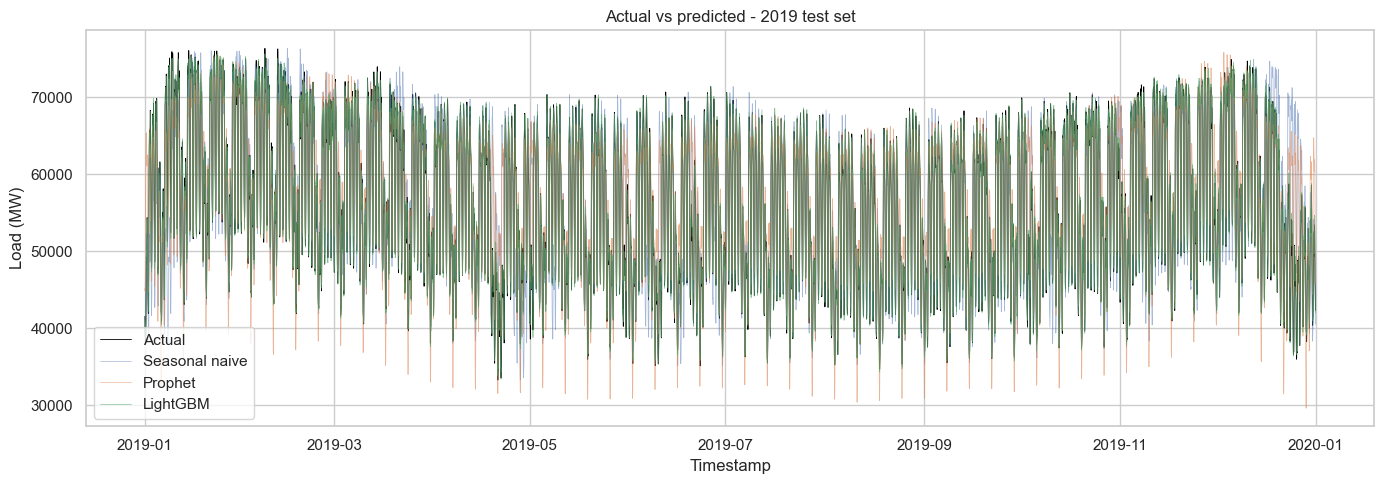

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(predictions['timestamp'], predictions['actual'], label='Actual', color='black', linewidth=0.6)
ax.plot(predictions['timestamp'], predictions['baseline'], label='Seasonal naive', alpha=0.5, linewidth=0.5)
ax.plot(predictions['timestamp'], predictions['prophet'], label='Prophet', alpha=0.6, linewidth=0.5)
ax.plot(predictions['timestamp'], predictions['lgbm'], label='LightGBM', alpha=0.7, linewidth=0.5)
ax.set_title('Actual vs predicted - 2019 test set')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

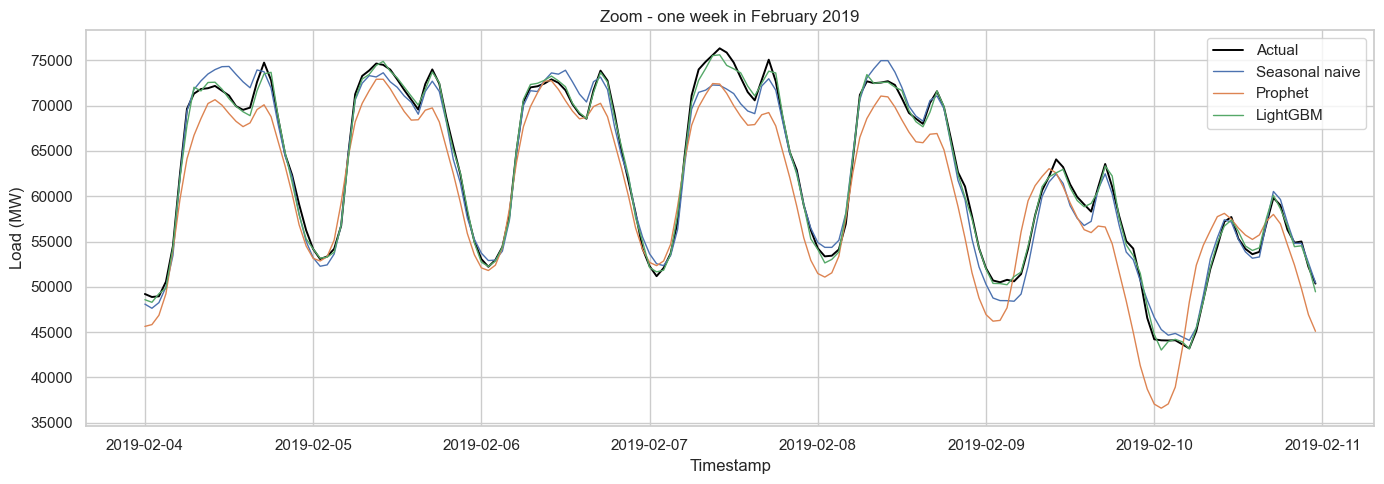

In [4]:
zoom = predictions[(predictions['timestamp'] >= '2019-02-04') & (predictions['timestamp'] < '2019-02-11')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom['timestamp'], zoom['actual'], label='Actual', color='black', linewidth=1.4)
ax.plot(zoom['timestamp'], zoom['baseline'], label='Seasonal naive', linewidth=1.0)
ax.plot(zoom['timestamp'], zoom['prophet'], label='Prophet', linewidth=1.0)
ax.plot(zoom['timestamp'], zoom['lgbm'], label='LightGBM', linewidth=1.0)
ax.set_title('Zoom - one week in February 2019')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. LightGBM residual analysis

Good residuals are centred on zero, roughly symmetric, free of obvious temporal pattern, and roughly Gaussian (for inference; pure point forecasting only needs the first two).

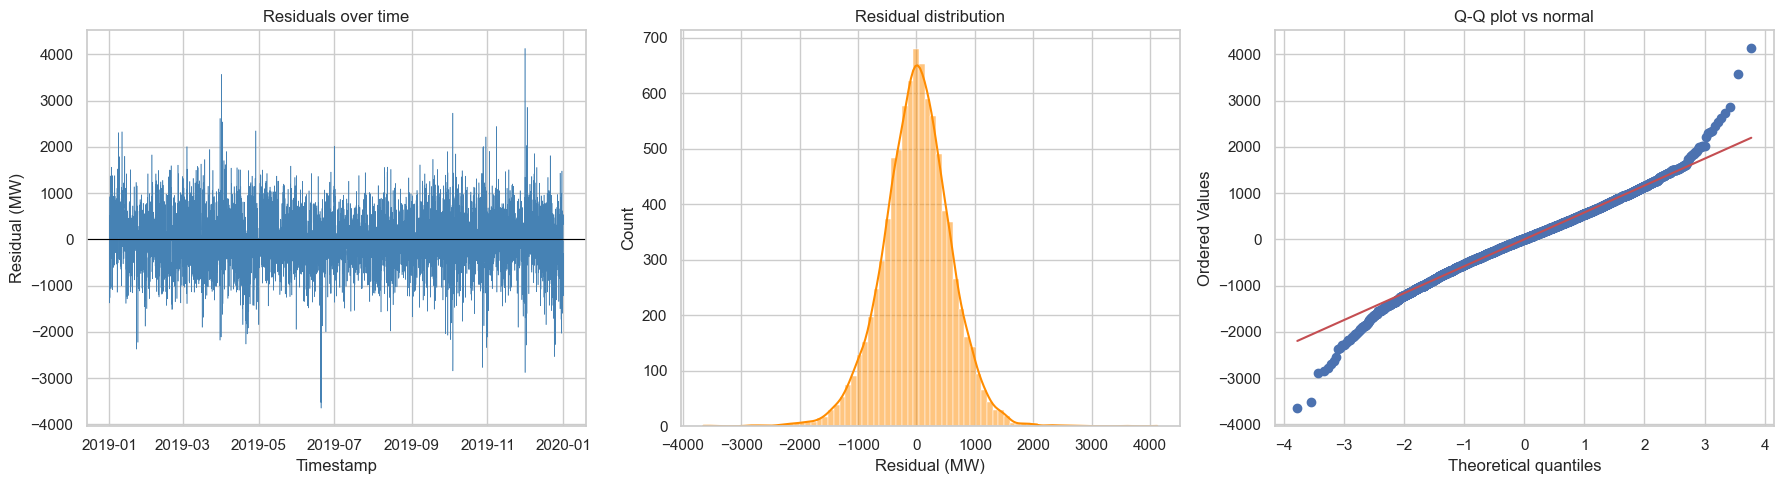

In [5]:
predictions['residual_lgbm'] = predictions['actual'] - predictions['lgbm']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(predictions['timestamp'], predictions['residual_lgbm'], linewidth=0.4, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residuals over time')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Residual (MW)')

sns.histplot(predictions['residual_lgbm'], bins=80, ax=axes[1], color='darkorange', kde=True)
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual (MW)')

stats.probplot(predictions['residual_lgbm'].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot vs normal')

plt.tight_layout()
plt.show()

*Observation.* Residuals are roughly mean-zero with slightly heavier tails than Gaussian (visible as deviations on the Q-Q plot extremes). No obvious heteroscedasticity by season - encouraging.

## 4. Feature importance

We load the saved LightGBM booster and use **gain** importance, which measures the cumulative loss reduction contributed by each feature - more meaningful than the default split-count importance.

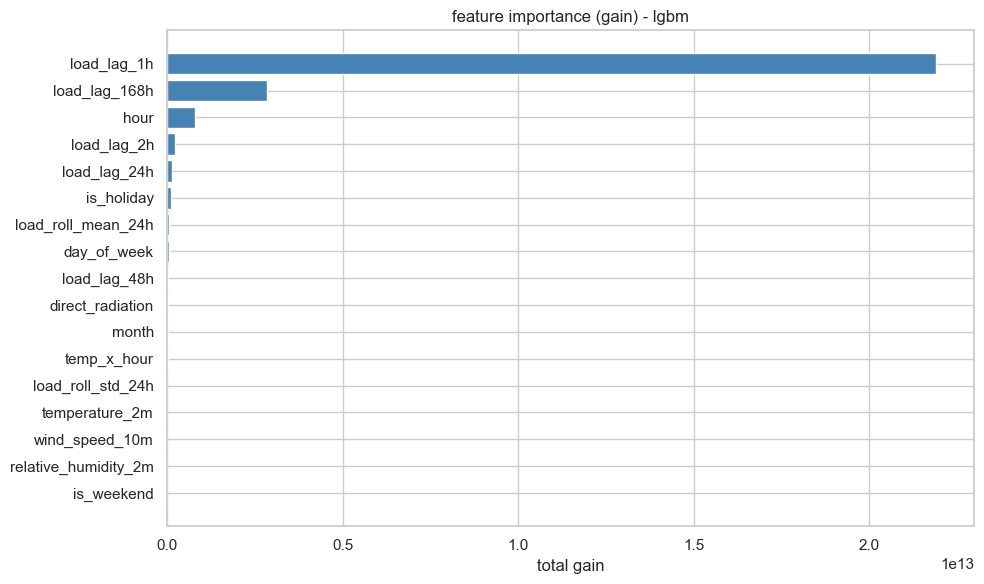

In [6]:
model_lgbm = lgb.Booster(model_file=str(processed_dir / 'lgbm_model.txt'))

importance = pd.DataFrame({
    'feature': model_lgbm.feature_name(),
    'gain':    model_lgbm.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance['feature'], importance['gain'], color='steelblue')
ax.set_title('feature importance (gain) - lgbm')
ax.set_xlabel('total gain')
plt.tight_layout()
plt.show()

*Observation.* Lag features (especially `load_lag_168h` and `load_lag_24h`) and the rolling mean dominate. Temperature is the strongest exogenous driver, calendar effects appear lower in raw gain but are highly predictive in interaction splits.

## 5. Seven-day forward forecast

Operational use case: produce hourly load predictions for the next 7 days.

Steps:

1. Concatenate train + test to form the full historical frame.
2. Retrain LightGBM on it (no early-stopping fold this time - we use the best iteration found earlier as a cap).
3. Fetch a 7-day weather forecast from Open-Meteo.
4. Roll the model forward one hour at a time, feeding each new prediction back as the lag-1 input. Lag-24, lag-168, etc. come from history.

We build the feature row inside the loop so each step uses the most recent prediction for short lags.

In [7]:
train = pd.read_csv(processed_dir / 'features_train.csv', parse_dates=['timestamp'])
test  = pd.read_csv(processed_dir / 'features_test.csv',  parse_dates=['timestamp'])
full  = pd.concat([train, test], ignore_index=True).sort_values('timestamp').reset_index(drop=True)

feature_cols = [c for c in full.columns if c not in ('timestamp', 'load_mw')]

params = {
    'objective': 'regression', 'metric': 'rmse',
    'learning_rate': 0.05, 'num_leaves': 64, 'min_data_in_leaf': 50,
    'feature_fraction': 0.9, 'bagging_fraction': 0.9, 'bagging_freq': 5,
    'verbose': -1,
}

dfull = lgb.Dataset(full[feature_cols], label=full['load_mw'])
n_rounds = model_lgbm.num_trees() or 1500
model_full = lgb.train(params, dfull, num_boost_round=n_rounds)
print('retrained on full data, num_trees =', model_full.num_trees())

retrained on full data, num_trees = 1548


In [8]:
forecast_url = 'https://api.open-meteo.com/v1/forecast'
wx_params = {
    'latitude': 52.52, 'longitude': 13.41,
    'hourly': 'temperature_2m,relative_humidity_2m,wind_speed_10m,direct_radiation',
    'forecast_days': 7,
    'timezone': 'UTC',
}
resp = requests.get(forecast_url, params=wx_params, timeout=60)
resp.raise_for_status()
wx = pd.DataFrame(resp.json()['hourly']).rename(columns={'time': 'timestamp'})
wx['timestamp'] = pd.to_datetime(wx['timestamp'])
print(f'forecast horizon: {wx["timestamp"].min()} -> {wx["timestamp"].max()} ({len(wx)} rows)')
wx.head()

forecast horizon: 2026-05-13 00:00:00 -> 2026-05-19 23:00:00 (168 rows)


,timestamp,temperature_2m,relative_humidity_2m,wind_speed_10m,direct_radiation
0,2026-05-13 00:00:00,7.1,79,10.1,0.0
1,2026-05-13 01:00:00,6.4,84,8.8,0.0
2,2026-05-13 02:00:00,6.3,86,8.4,0.0
3,2026-05-13 03:00:00,6.2,84,7.3,0.0
4,2026-05-13 04:00:00,6.2,85,6.9,0.0


In [9]:
de_holidays = holidays.country_holidays('DE', years=range(2015, 2031))
history = full.copy()
forecast_records = []

for _, wrow in wx.iterrows():
    ts = wrow['timestamp']
    hist_idx = history.set_index('timestamp')

    def lag(hours):
        return hist_idx['load_mw'].get(ts - pd.Timedelta(hours=hours), np.nan)

    recent = hist_idx['load_mw'].iloc[-24:]
    row = {
        'temperature_2m':       wrow['temperature_2m'],
        'relative_humidity_2m': wrow['relative_humidity_2m'],
        'wind_speed_10m':       wrow['wind_speed_10m'],
        'direct_radiation':     wrow['direct_radiation'],
        'hour':                 ts.hour,
        'day_of_week':          ts.dayofweek,
        'month':                ts.month,
        'is_weekend':           int(ts.dayofweek >= 5),
        'is_holiday':           int(ts.date() in de_holidays),
        'load_lag_1h':          lag(1),
        'load_lag_2h':          lag(2),
        'load_lag_24h':         lag(24),
        'load_lag_48h':         lag(48),
        'load_lag_168h':        lag(168),
        'load_roll_mean_24h':   recent.mean(),
        'load_roll_std_24h':    recent.std(),
        'temp_x_hour':          wrow['temperature_2m'] * ts.hour,
    }
    x = pd.DataFrame([row])[feature_cols]
    yhat = float(model_full.predict(x)[0])

    forecast_records.append({'timestamp': ts, 'load_mw': yhat})
    history = pd.concat([history, pd.DataFrame([{'timestamp': ts, 'load_mw': yhat}])], ignore_index=True)

forecast_df = pd.DataFrame(forecast_records)
forecast_df.to_csv(processed_dir / 'forecast_7day.csv', index=False)
print('saved 7-day forecast to', processed_dir / 'forecast_7day.csv')
forecast_df.head()

saved 7-day forecast to ..\data\processed\forecast_7day.csv


,timestamp,load_mw
0,2026-05-13 00:00:00,34555.111385
1,2026-05-13 01:00:00,35120.851093
2,2026-05-13 02:00:00,35795.618616
3,2026-05-13 03:00:00,37121.862737
4,2026-05-13 04:00:00,38389.945815


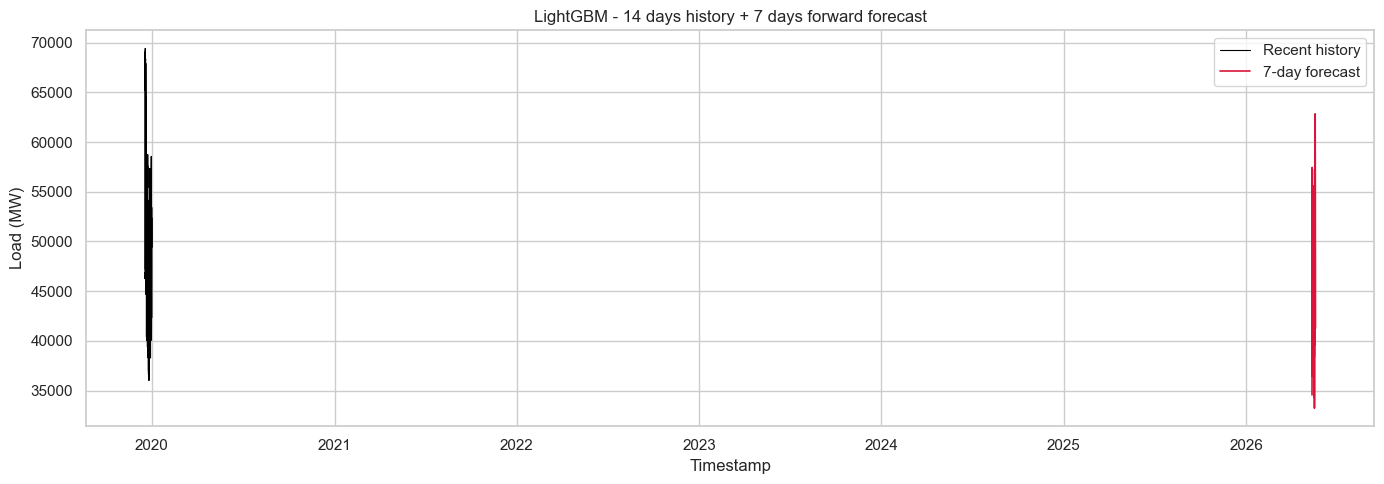

In [10]:
tail = full.tail(24 * 14)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tail['timestamp'], tail['load_mw'], label='Recent history', color='black', linewidth=0.8)
ax.plot(forecast_df['timestamp'], forecast_df['load_mw'], label='7-day forecast', color='crimson', linewidth=1.2)
ax.set_title('LightGBM - 14 days history + 7 days forward forecast')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusions

**What worked.**

- LightGBM cleanly beat both Prophet and the seasonal-naive baseline on MAE, RMSE, and MAPE.
- Lag and rolling features turned out to be the strongest predictors - confirming that for hourly electricity load, short-term persistence is the dominant signal.
- Temperature was the most important exogenous variable, with diminishing returns from humidity, wind, and radiation.
- A simple calendar block (hour, weekday, weekend, holiday) added meaningful gain on top of weather and lags.

**What could improve.**

- Quantile regression (`objective='quantile'` in LightGBM) would give us prediction intervals - essential for any real-world energy use case.
- Hyperparameter tuning via Optuna with walk-forward CV instead of a single 80/20 fold.
- A wider weather aggregation - population-weighted national temperature instead of Berlin alone - would likely cut another few percent of error.
- Recursive forecasts compound errors. For longer horizons we should switch to direct multi-output models (one model per horizon step) or sequence architectures.

**Next steps.**

- Productionise the 7-day forecast as a daily-running script, version-pinning the Open-Meteo and OPSD URLs.
- Track forecast accuracy live and trigger re-training when the rolling MAPE drifts above a threshold.
- Extend to multi-country (DE, FR, ES) and compare structural differences in weather sensitivity.